In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from scipy.stats import linregress


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights


def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def box_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean


In [381]:
fp = '/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Amon/ts/gr/latest/ts_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.nc'
ds = xr.open_dataset(fp)

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [382]:
#nino34
sst34 = ds.sel(lon=slice(360-170.,360-120.), lat=slice(-5,5))


#compute sst weights
sst_weights = build_weights(sst34, sst34.ts)

#compute box mean
sst_boxmean = box_mean(sst34, sst34.ts, sst_weights)

#compute anomalies as nino34 index
nino34_model = anomaly(sst_boxmean, sst_weights, detrend = False)
nino34_model = nino34_model.rename('nino34_index')   # change variable name 


In [354]:
#ninowest
sstwest = ds.sel(lon=slice(130.,150.), lat=slice(0,15))


#compute sst weights
sst_weights = build_weights(sstwest, sstwest.ts)

#compute box mean
sst_boxmean = box_mean(sstwest, sstwest.ts, sst_weights)

#compute anomalies as ninowest index
ninowest_model = anomaly(sst_boxmean, sst_weights, detrend = False)
ninowest_model = ninowest_model.rename('ninowest_index')   # change variable name 


# SST

In [475]:
fp = '/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Amon/ts/gr/latest/ts_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.nc'
ds = xr.open_dataset(fp)

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [476]:
#nino34
sst34 = ds.sel(lon=slice(360-170.,360-120.), lat=slice(-5,5))


#compute sst weights
sst_weights = build_weights(sst34, sst34.ts)

#compute box mean
sst_boxmean = box_mean(sst34, sst34.ts, sst_weights)

#compute anomalies as nino34 index
nino34_model = anomaly(sst_boxmean, sst_weights, detrend = False)
nino34_model = nino34_model.rename('nino34_index')   # change variable name 


# Precip 

In [477]:
fp = '/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Amon/pr/gr/latest/pr_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.nc'
ds = xr.open_dataset(fp)


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [478]:
 
#select west
tp_west = ds.sel(lat = slice(-20,20), lon = slice(130, 150))

tp_weights = np.cos(np.deg2rad(tp_west.lat))
tp_west_mean = box_mean(tp_west, tp_west.pr, tp_weights).rolling(time = 3, center = True).mean()


In [479]:
#compute the anomaly
tp_west_anom = anomaly(tp_west_mean, tp_weights, detrend = False)

tp_west['box_mean'] = tp_west_mean*24*3600
tp_west['anom'] = tp_west_anom*24*3600

## T2m

In [480]:
fp = '/bdd/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Amon/tas/gr/latest/tas_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.nc'
ds = xr.open_dataset(fp)


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [481]:
w = np.cos(np.deg2rad(ds.lat))

gt = ds.tas.weighted(w).mean(['lat', 'lon'])

In [482]:
gt_y = gt.groupby('time.year').mean()
gt_y = gt_y - gt.mean()

dt = gt_y-gt_y.roll(year = 1)

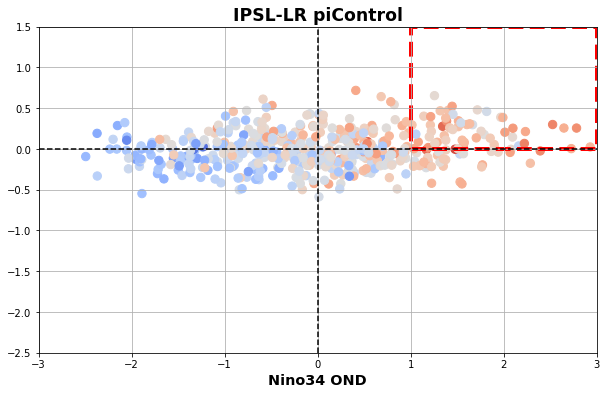

In [484]:
tp_y = tp_west.groupby('time.year').mean()
ninoOND = nino34_model.where(nino34_model.time.dt.month.isin([10,11,12])).groupby('time.year').mean()

fig, ax = plt.subplots(1,1, figsize = (10,6))

#ax.set_ylabel('Precip Rate West Anomaly [mm/day]')
ax.set_xlabel('Nino34 OND')
ax.set_title('IPSL-LR piControl')
ax.set_ylim(-2.5, 1.5)
ax.set_xlim(-3,3)

ax.axhline(0, linestyle = '--', c= 'k')
ax.axvline(0, linestyle = '--', c= 'k')

# Define the coordinates and dimensions of the rectangle
x_min, x_max = 1, 3
y_min, y_max = 0, 1.5
width = x_max - x_min
height = y_max - y_min

# Create a rectangle patch
rectangle = patches.Rectangle((x_min, y_min), width, height, linewidth=4, edgecolor='red', linestyle='--', fill=False)

# Add the rectangle patch to the plot
ax.add_patch(rectangle)




cmap = ax.scatter(y = tp_y.anom, x = ninoOND.data, c = dt, cmap = 'coolwarm', s= 70, vmin = -0.5, vmax = 0.5)

#for i in range(1,len(dt2m.t2m)):
 #   plt.arrow(y = tp_cumsept.isel(year = i).tp, x = ninoOND.isel(year = i).nino34, 
  #            dy =-(tp_cumsept.isel(year = i)-tp_cumsept.isel(year = (i-1))).tp/10,
   #           dx = -(ninoOND.isel(year=i).nino34-ninoOND.isel(year=(i-1)).nino34)/10)
#fig.colorbar(cmap, label = r'Δ TAS' ,use_gridspec = True)
ax.set_ylim(-2.5, 1.5)
#ax.yaxis.set_ticks([])




plt.grid()
plt.show()

# MPI

In [3]:
fp = '/data/jmex/models/MPI-M/pr_merged.nc'
ds = xr.open_dataset(fp)

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [4]:
 
#select west
tp_west = ds.sel(lat = slice(-20,20), lon = slice(130, 150))

tp_weights = np.cos(np.deg2rad(tp_west.lat))
tp_west_mean = box_mean(tp_west, tp_west.pr, tp_weights).rolling(time = 3, center = True).mean()


In [5]:
#compute the anomaly
tp_west_anom = anomaly(tp_west_mean, tp_weights, detrend = False)

tp_west['box_mean'] = tp_west_mean*24*3600
tp_west['anom'] = tp_west_anom*24*3600

tp_y = tp_west.groupby('time.year').mean()
tp_y = tp_y/tp_y.std()

In [6]:

fp = '/data/jmex/models/MPI-M/ts_merged.nc'
ds = xr.open_dataset(fp)


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [7]:
#nino34
sst34 = ds.sel(lon=slice(360-170.,360-120.), lat=slice(-5,5))


#compute sst weights
sst_weights = build_weights(sst34, sst34.ts)

#compute box mean
sst_boxmean = box_mean(sst34, sst34.ts, sst_weights)

#compute anomalies as nino34 index
nino34_model = anomaly(sst_boxmean, sst_weights, detrend = False)
nino34_model = nino34_model.rename('nino34_index')   # change variable name 

ninoOND = nino34_model.where(nino34_model.time.dt.month.isin([10,11,12])).groupby('time.year').mean()

ninoOND = ninoOND/ninoOND.std()

In [8]:
fp = '/data/jmex/models/MPI-M/tas_merged.nc'
ds = xr.open_dataset(fp)

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


In [9]:
w = np.cos(np.deg2rad(ds.lat))

gt = ds.tas.weighted(w).mean(['lat', 'lon'])

In [10]:
gt_y = gt.groupby('time.year').mean()
gt_y = gt_y - gt.mean()

dt = gt_y-gt_y.roll(year = 1)

dt =   dt/dt.std()

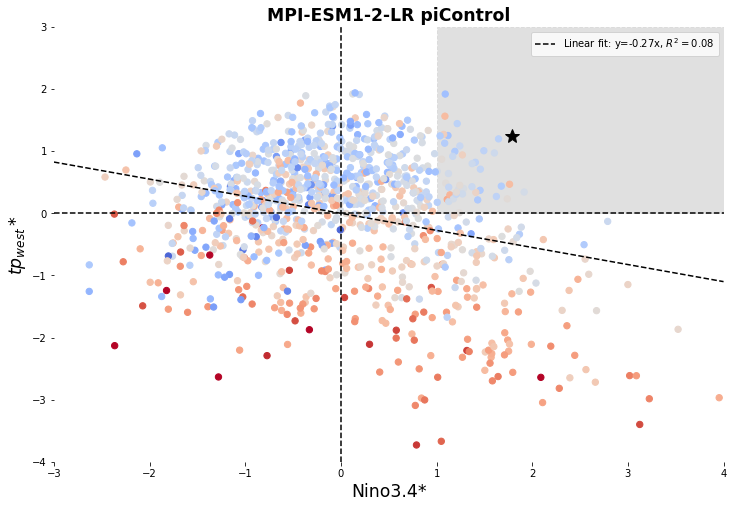

In [14]:

fig, ax = plt.subplots(1,1, figsize = (12,8))

# Hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)


ax.set_ylim(-4, 3)
ax.set_xlim(-3, 4)
ax.set_ylabel(r'$tp_{west}*$', fontsize = 'xx-large')
ax.set_xlabel(r'Nino3.4*', fontweight='normal', fontsize = 'xx-large')
ax.set_title('MPI-ESM1-2-LR piControl')

ax.axhline(0, linestyle='--', c='k')
ax.axvline(0, linestyle='--', c='k')

# Define the coordinates and dimensions of the shaded area
x_min, x_max = 1, 4
y_min, y_max = 0, 3

# Shade the rectangular area
ax.fill_betweenx(y=[y_min, y_max], x1=x_min, x2=x_max, color='lightgrey', alpha=0.7, linestyle='--')


# Fit a regression line to the collected points
slope, intercept, r_value, p_value, std_err = linregress(y = tp_y.anom, x = ninoOND.data)

# Plot the regression line
x_vals = np.array(ax.get_xlim())
y_vals = intercept + slope * x_vals
ax.plot(x_vals, y_vals, '--', color='k', label=f'Linear fit: y={slope:.2f}x, $R^2={r_value**2:.2f}$')

ax.plot(1.79, 1.25, marker='*', color='black', markersize=15, linestyle = ' ')


#cmap = ax.scatter(y = tp_y.anom, x = ninoOND.data, c = dt, cmap = 'coolwarm', s= 30, vmin = -3, vmax = 3)
cmap = ax.scatter(y = tp_y.anom, x = ninoOND.data, c = ninoOND.roll(year = 1).data, cmap = 'coolwarm', s= 40, vmin = -3, vmax = 3)


#fig.colorbar(cmap, label = r'Δ TAS' ,use_gridspec = True)
ax.legend()
plt.show()

In [23]:
# Calculate the ratio of points inside the shaded area
inside = ((ninoOND.data >= x_min) & (ninoOND.data <= x_max) &
          (tp_y.anom >= y_min) & (tp_y.anom <= y_max))

ratio = np.sum(inside) / len(ninoOND.data)
print("Ratio of points inside the shaded area: {}".format(ratio.data))


Ratio of points inside the shaded area: 0.043


In [12]:
ninoOND.roll(year = 1)

<xarray.DataArray 'nino34_index' (year: 1000)>
array([ 3.20649582e-01, -6.06810315e-01, -2.99190016e-01, -5.29122508e-01,
        3.34166522e-01,  2.36472318e-01,  3.52473162e+00, -1.27999452e+00,
       -1.87360330e+00, -3.55691106e-01, -9.79603186e-01,  2.81192209e-01,
        1.47060369e+00,  1.10368219e+00, -1.91049842e+00,  6.50143516e-01,
       -1.72256548e-01, -1.95698633e-01, -2.33677511e-01,  1.00651126e+00,
        4.39812983e-01, -3.07600627e-01,  6.67966632e-01,  2.93128793e-01,
       -1.66311475e+00,  2.00823997e-01, -9.02290891e-01,  1.19122121e+00,
        3.95434856e+00, -3.29684769e-01, -1.23293020e+00, -1.12843283e+00,
       -1.86722926e+00, -6.74243959e-01,  1.21565470e+00,  1.94662001e-02,
        2.25603351e-01, -8.13672579e-01,  6.84310800e-02,  1.23838270e+00,
        8.41891779e-01, -6.03215317e-01, -1.06441038e-02, -2.79158675e-02,
       -1.57264010e+00, -8.14179033e-01,  6.44326153e-01,  1.71057108e+00,
       -1.00931375e+00,  4.84626764e-01,  1.41653289e+00, -1.80422592e+00,
       -1.16474626e+00,  7.57101334e-01, -2.61373151e-01,  4.27850484e-02,
        2.75989761e-01,  1.15399779e+00, -4.18789793e-01, -6.75076816e-01,
        5.13300858e-01,  3.66177431e-01, -1.63793734e+00, -1.63697459e-01,
        3.71594015e-01, -1.07897566e-01, -1.09524087e+00,  1.11914252e+00,
        1.32275460e+00, -1.05899994e+00, -1.27029670e+00, -6.96578607e-01,
        1.64762700e+00,  8.61910178e-01,  1.57838625e+00,  8.18148622e-01,
       -1.26115145e+00, -1.28196859e+00,  7.05243067e-01,  4.71585238e-02,
...
       -1.31012656e+00, -8.61248311e-02, -1.64500714e-01,  6.59159513e-01,
        1.42022623e+00, -1.31109468e-01, -1.13782741e+00,  6.05292233e-02,
        4.89679323e-01,  1.15287768e+00, -1.42054135e-01, -1.00811147e-01,
       -4.23022588e-01,  1.24328559e+00,  1.04859361e+00,  1.71805765e+00,
       -2.01652173e-01, -5.61342568e-02,  7.44723230e-01, -1.70383127e+00,
       -1.96534041e-01,  3.01737606e-02, -8.16721788e-01, -9.89933368e-01,
       -1.31615031e+00,  2.82137228e-02,  8.34827826e-01,  9.13863738e-02,
       -1.74902810e-01,  4.29617731e-01,  4.19588148e-01,  8.72125823e-01,
        1.18469380e-01, -2.41219771e-01, -1.08175075e+00,  1.06186433e-01,
        1.20699205e+00,  1.00632986e+00, -5.12086749e-01, -2.81482822e-01,
        6.83970819e-01,  1.90543548e+00,  1.01159944e+00, -1.15973939e+00,
       -7.75559031e-01, -7.08755949e-01, -4.79721852e-01, -2.03591313e-01,
        6.99954531e-01, -4.55853391e-01, -7.59204919e-01,  1.00687057e+00,
        1.78717378e+00,  3.22387251e+00, -2.36513099e+00, -1.16398485e+00,
       -3.46612420e-01,  1.60420428e+00, -1.07968191e+00, -6.46464830e-01,
       -2.26501428e-01,  1.83818013e+00,  1.34094465e+00, -6.92995908e-01,
       -4.10072915e-01, -8.87293210e-01,  6.86953681e-01,  6.40082511e-01,
        2.65957567e+00,  7.89908202e-01, -1.08662538e+00, -8.71351005e-01,
       -9.61369957e-01, -2.74443122e-01,  1.30997762e+00, -5.24922716e-01,
       -4.27791951e-01, -4.17495300e-01, -1.16913000e+00,  3.96467161e-01])
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2845 2846 2847 2848 2849